# Appendix Plots

Generates appendix figures: runtime scaling and probability sensitivity curves.
Reads the same MLflow experiments as the main performance notebook.

**Input:** MLflow experiments `final-3-{dataset}-25`  
**Output:** `output/` (appendix runtime and probability plots)

In [1]:
import matplotlib.pyplot as plt
import mlflow

from utils_run import get_single_result_table
from utils_plot import find_run, get_and_preprocess_run

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Connected to http://localhost:5000


## Plot function

In [2]:
def make_final_plot(dataset_name, run_specs, ax=None, postfix=""):
    ax_ = plt.subplots()[1] if ax is None else ax
    for i, run_name in enumerate(run_specs.keys()):
        #ax_.fill_between(df["axis"],
        #                 df["mean"] - df["std"],
        #                 df["mean"] + df["std"],
        #                 alpha=0.1, color=COLORS[i])

        if run_name.startswith("_") and not dataset_name in run_name:
            continue

        run_name_short = run_name.split("_")[-1]
        df = get_and_preprocess_run(dataset_name, run_name_short)

        ax_.plot(df["axis"], df["mean"],
                 color=run_specs[run_name][2],
                 ls=run_specs[run_name][1],
                 label=run_specs[run_name][0])

    plt.title(f"Dataset: {dataset_name}", fontsize=20)
    plt.xlabel("Fraction Data Removed", fontsize=20)
    plt.ylabel("Accuracy", fontsize=20)
    plt.legend(fontsize=18)
    plt.tight_layout()
    plt.savefig(f"output/{dataset_name}{postfix}.pdf")
    plt.show()


## Generate figures

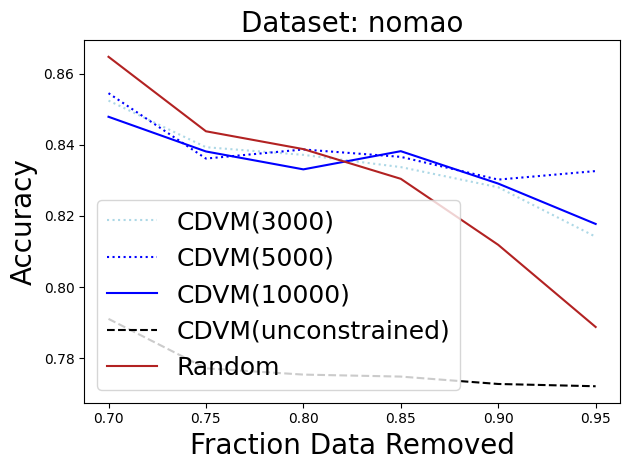

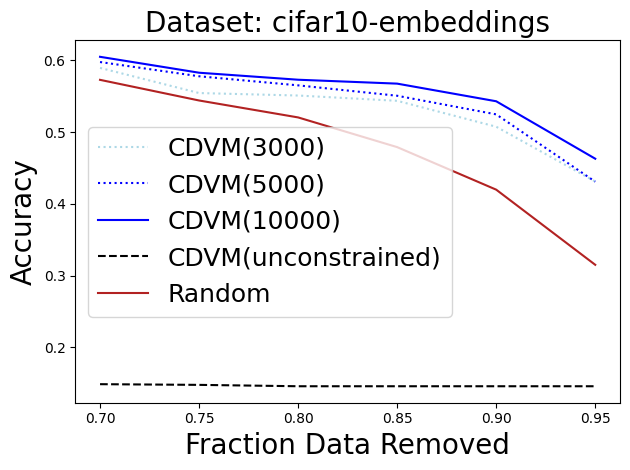

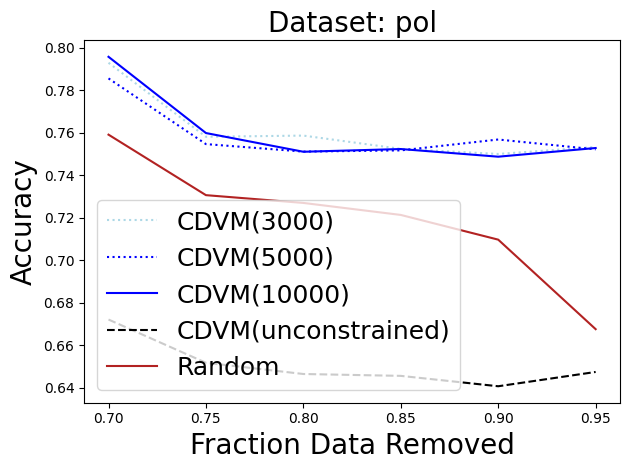

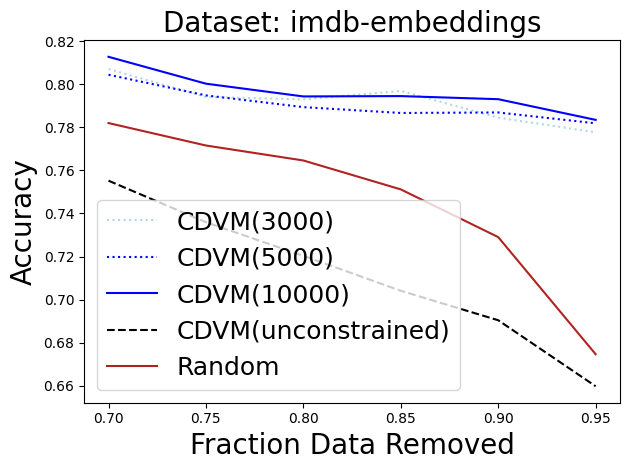

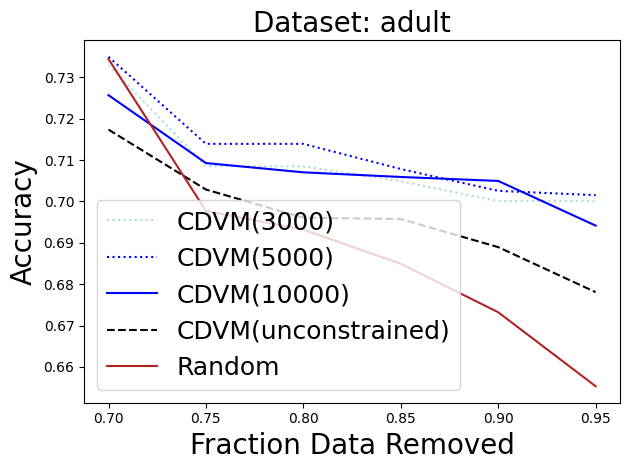

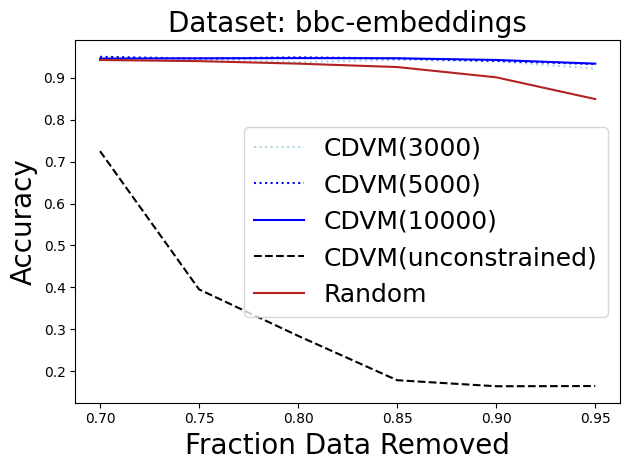

In [3]:
run_specs = {"DataAttrOpt(3000, 0.03, 15, best, +b, alpha=best)": ["CDVM(3000)", ":", "lightblue"],
             "DataAttrOpt(5000, 0.03, 15, best, +b, alpha=best)": ["CDVM(5000)", ":", "blue"],
             "DataAttrOpt(10000, 0.03, 15, best, +b, alpha=best)": ["CDVM(10000)", "-", "blue"],
             "DataAttrOpt(10000, 0.03, 15, inf, +b, alpha=1.0)": ["CDVM(unconstrained)", "--", "black"],
             "RandomEvaluator()": ["Random", "-", "firebrick"]
             }

make_final_plot("nomao", run_specs, postfix="-appendix_runtime")
make_final_plot("cifar10-embeddings", run_specs, postfix="-appendix_runtime")
make_final_plot("pol", run_specs, postfix="-appendix_runtime")
make_final_plot("imdb-embeddings", run_specs, postfix="-appendix_runtime")
make_final_plot("adult", run_specs, postfix="-appendix_runtime")
make_final_plot("bbc-embeddings", run_specs, postfix="-appendix_runtime")

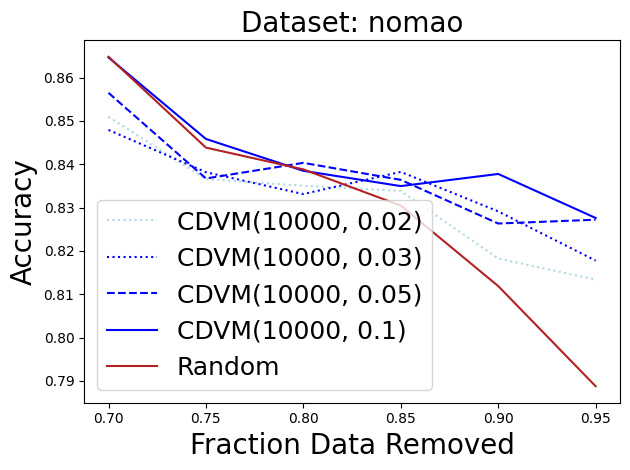

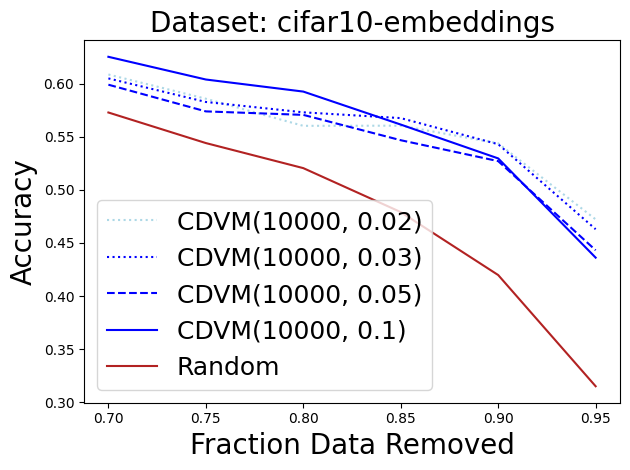

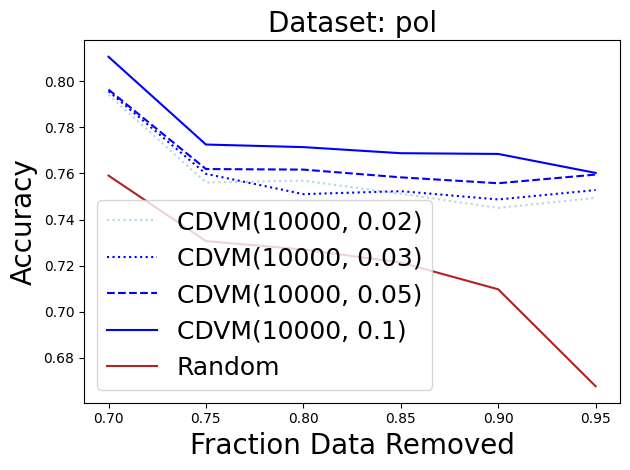

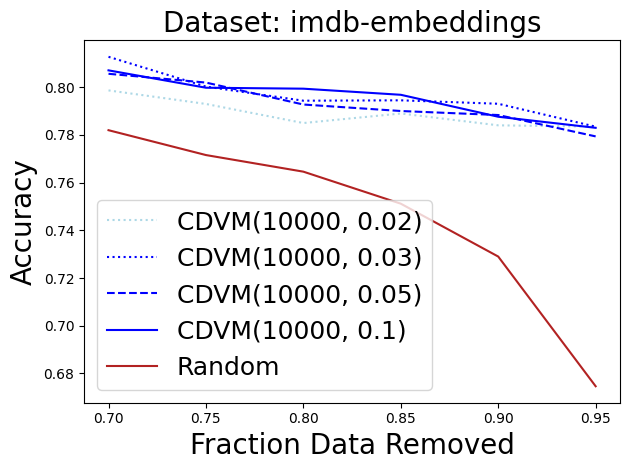

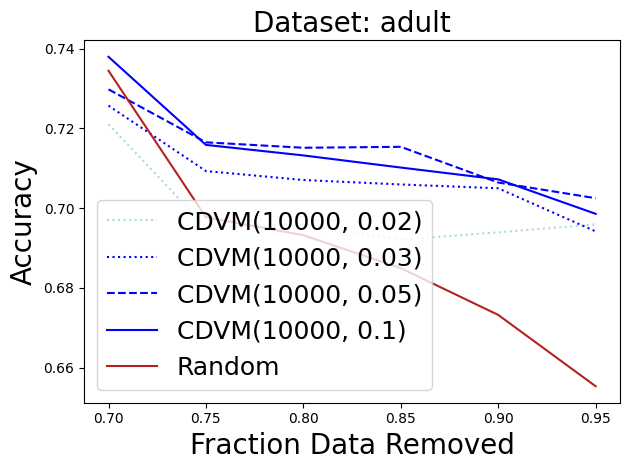

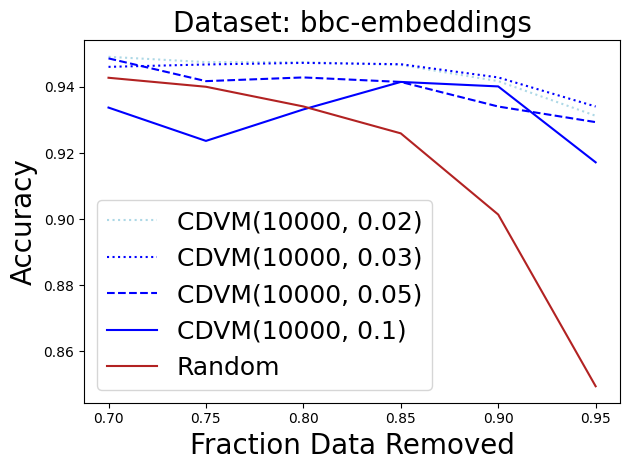

In [4]:
run_specs = {"DataAttrOpt(10000, 0.02, 15, best, +b, alpha=best)": ["CDVM(10000, 0.02)", ":", "lightblue"],
             "DataAttrOpt(10000, 0.03, 15, best, +b, alpha=best)": ["CDVM(10000, 0.03)", ":", "blue"],
             "DataAttrOpt(10000, 0.05, 15, best, +b, alpha=best)": ["CDVM(10000, 0.05)", "--", "blue"],
             "DataAttrOpt(10000, 0.1, 15, best, +b, alpha=best)": ["CDVM(10000, 0.1)", "-", "blue"],
             "RandomEvaluator()": ["Random", "-", "firebrick"]
             }

make_final_plot("nomao", run_specs, postfix="-appendix_p")
make_final_plot("cifar10-embeddings", run_specs, postfix="-appendix_p")
make_final_plot("pol", run_specs, postfix="-appendix_p")
make_final_plot("imdb-embeddings", run_specs, postfix="-appendix_p")
make_final_plot("adult", run_specs, postfix="-appendix_p")
make_final_plot("bbc-embeddings", run_specs, postfix="-appendix_p")